# Breathing in Danger


## Introduction


One of the most important environmental and health issues of our day is air pollution.  Air quality is frequently disregarded when people move or travel for work or personal reasons, despite the fact that it has a direct impact on productivity, human health, and general quality of life.  There are significant dangers associated with the rising concentrations of pollutants including PM2.5, CO, NO₂, and O₃, particularly in places that are industrial .

In order to identify the most polluted locations, comprehend the relationships between various contaminants, and ascertain which ones have the biggest impact on air quality, this project examines data on air pollution worldwide.  The results shows how urgently stricter environmental laws and increased public awareness are needed to ensure cleaner air and a healthier future for people everywhere.

## Audience

-Local Community / General Public

-Government or Policy Makers

-Companies and Industrial Organizations

## Dataset

link of the data (https://www.kaggle.com/datasets/hasibalmuzdadid/global-air-pollution-dataset)

Global air quality data for 23462 cities in 184 countries is given by the dataset.  The Air Quality Index (AQI) comprises both general and pollutant-specific values and categories. A city's measured air quality levels for various contaminants are represented by each record.


Country: The nation in which the city exists.

City: The local city that was measured.

AQI Value: (Air quality index) A value that shows the level of total air pollution.

AQI Category: The qualitative classification of air quality, which is Good, Moderate, Unhealthy for sensetive group,  Unhealthy, very Unhealthy, hazardous.

CO AQI Value / Category: The carbon monoxide levels' AQI value and category, which effect on breathing and plants.

Ozone AQI Value / Category:  AQI value and category for ozone levels, which effect on the heart and brain.

NO₂ AQI Value / Category: AQI value and category for nitrogen dioxide levels, which effect on the lungs.

PM2.5 AQI Value / Category: A value and classification that shows fine particles smaller than 2.5 microns in the air


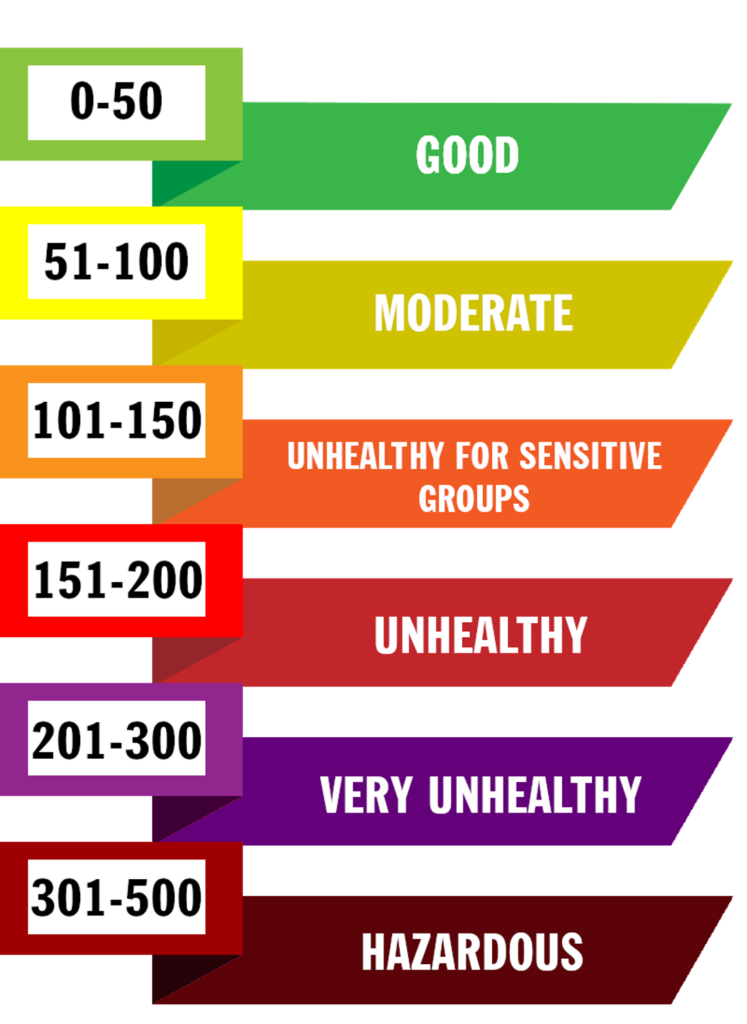

In [2]:
from IPython.display import Image, display
display(Image(filename="AQI.webp", width=300, height=400))


## Data Handling

#### Reading the file and importing the requirments

In [3]:
import pandas as pd

In [4]:
air_df = pd.read_csv('global air pollution dataset.csv', encoding='latin-1')# to read the csv file


In [5]:
air_df #taking a look at the raw data

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
23458,India,Gursahaiganj,184,Unhealthy,3,Good,154,Unhealthy,2,Good,184,Unhealthy
23459,France,Sceaux,50,Good,1,Good,20,Good,5,Good,50,Good
23460,India,Mormugao,50,Good,1,Good,22,Good,1,Good,50,Good
23461,United States of America,Westerville,71,Moderate,1,Good,44,Good,2,Good,71,Moderate


#### Data cleaning and exploration

In [6]:
air_df.info() # take a small look at the info 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


In [7]:
air_df.isnull().sum() #to see if there are missing value

Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

In [8]:
row,col=air_df.shape 
(air_df.isnull().sum()/row)*100 # to see the percent of missing information

Country               1.819887
City                  0.004262
AQI Value             0.000000
AQI Category          0.000000
CO AQI Value          0.000000
CO AQI Category       0.000000
Ozone AQI Value       0.000000
Ozone AQI Category    0.000000
NO2 AQI Value         0.000000
NO2 AQI Category      0.000000
PM2.5 AQI Value       0.000000
PM2.5 AQI Category    0.000000
dtype: float64

In [9]:
air_df.shape # more information

(23463, 12)

In [10]:
air_df[air_df.isnull().any(axis=1)]
# to see where are the missing value


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
535,NaN,Granville,30,Good,1,Good,30,Good,3,Good,25,Good
654,NaN,Kingston Upon Hull,33,Good,1,Good,17,Good,8,Good,33,Good
787,NaN,New Waterford,20,Good,1,Good,18,Good,9,Good,20,Good
801,NaN,Kingstown,163,Unhealthy,0,Good,25,Good,0,Good,163,Unhealthy
906,NaN,Nanakuli,30,Good,0,Good,27,Good,0,Good,30,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
22979,NaN,Kyaikkami,54,Moderate,0,Good,20,Good,0,Good,54,Moderate
23115,NaN,Bima,25,Good,1,Good,25,Good,0,Good,24,Good
23311,NaN,Marapanim,25,Good,1,Good,15,Good,0,Good,25,Good
23345,NaN,Calbuco,36,Good,1,Good,15,Good,3,Good,36,Good


In [11]:
miss_df=air_df[air_df.isnull().any(axis=1)]
miss_df # to know all the cities for missing country

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
535,NaN,Granville,30,Good,1,Good,30,Good,3,Good,25,Good
654,NaN,Kingston Upon Hull,33,Good,1,Good,17,Good,8,Good,33,Good
787,NaN,New Waterford,20,Good,1,Good,18,Good,9,Good,20,Good
801,NaN,Kingstown,163,Unhealthy,0,Good,25,Good,0,Good,163,Unhealthy
906,NaN,Nanakuli,30,Good,0,Good,27,Good,0,Good,30,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
22979,NaN,Kyaikkami,54,Moderate,0,Good,20,Good,0,Good,54,Moderate
23115,NaN,Bima,25,Good,1,Good,25,Good,0,Good,24,Good
23311,NaN,Marapanim,25,Good,1,Good,15,Good,0,Good,25,Good
23345,NaN,Calbuco,36,Good,1,Good,15,Good,3,Good,36,Good


In [12]:
print(air_df['Country'].unique()) # to see all country include in dataset

['Russian Federation' 'Brazil' 'Italy' 'Poland' 'France'
 'United States of America' 'Germany' 'Belgium' 'Egypt' 'China'
 'Netherlands' 'India' 'Pakistan' 'Republic of North Macedonia' 'Colombia'
 'Romania' 'Indonesia' 'Finland' 'South Africa'
 'United Kingdom of Great Britain and Northern Ireland'
 'United Republic of Tanzania' 'Haiti' 'Somalia' 'Philippines' 'Latvia'
 'Chad' 'New Zealand' 'Tunisia' 'Viet Nam' 'Iran (Islamic Republic of)'
 'Mexico' 'Japan' 'El Salvador' 'Bulgaria' 'Nigeria' 'South Sudan'
 'Guatemala' 'Ireland' 'Turkey' 'Peru' 'Democratic Republic of the Congo'
 'Canada' 'Switzerland' 'Denmark' 'Cameroon' 'Australia' 'Portugal'
 "Côte d'Ivoire" 'Sweden' 'Ethiopia' 'Thailand' 'Hungary' 'Kazakhstan'
 'Israel' 'Spain' 'Myanmar' 'Papua New Guinea' 'Madagascar' 'Lithuania'
 'Ghana' 'Azerbaijan' 'Armenia' 'Ukraine' 'Malaysia' 'Serbia' 'Slovakia'
 'Gambia' 'Ecuador' 'Bosnia and Herzegovina' 'Czechia' 'Argentina'
 'Dominican Republic' 'Guinea' 'Bolivia (Plurinational State of)

In [13]:
print(miss_df['City'].unique()) # to see all cities for missing country

['Granville' 'Kingston Upon Hull' 'New Waterford' 'Kingstown' 'Nanakuli'
 'Lavagna' 'Ladispoli' 'Dong Hoi' 'Nettuno' 'Puebloviejo' 'Fiumicino'
 'Nishinomiya' 'Carteret' 'Ercolano' 'Bolama' 'Bairiki' 'Broome'
 'Cananeia' 'Cavite' 'Prince Rupert' 'Roseau' 'Ardrossan' 'Stockholm'
 'Tacloban' 'Tadotsu' 'Ternate' 'Torre Del Greco' 'Broadstairs'
 'Ermoupolis' 'Parainen' 'Piombino' 'Pomorie' 'Port Dickson' 'Puerto Real'
 'Rottingdean' 'Sakaiminato' 'San Jose' 'Savona' 'Sines' 'Oarai'
 'Keansburg' 'Juneau' 'Santa Pola' 'Sawtell' 'Sinop' nan 'Kalianget'
 'Futtsu' 'Gingoog' 'Caibarien' 'Caminawit' 'Balikpapan' 'Golcuk'
 'Gold Coast' 'Hambantota' 'Isla Mujeres' 'Santa Flavia' 'Crotone'
 'Vieste' 'Moche' 'Namerikawa' 'Menton' 'Zanzibar' 'Domoni' 'West Bay'
 'Wakkanai' 'San Benedetto Del Tronto' 'Sao Francisco Do Sul' 'Anacortes'
 'Banjul' 'New York' 'Akcakoca' 'Alcudia' 'Titusville' 'Togitsu' 'Velsen'
 'Dinard' 'Split' 'Port De Bouc' 'Pulupandan' 'Pambujan' 'Papara' 'Maxixe'
 'Mazatlan' 'Monster' 

In [14]:
air_df = pd.read_csv("global air pollution dataset.csv", encoding="latin1")
# to fill the missing country
city_to_country = {
    "Kingston Upon Hull": "United Kingdom of Great Britain and Northern Ireland",
    "New Waterford": "Canada",
    "Kingstown": "Saint Vincent and the Grenadines",
    "Nanakuli": "United States of America",
    "Lavagna": "Italy",
    "Ladispoli": "Italy",
    "Dong Hoi": "Viet Nam",
    "Nettuno": "Italy",
    "Puebloviejo": "Colombia",
    "Fiumicino": "Italy",
    "Nishinomiya": "Japan",
    "Carteret": "United States of America",
    "Ercolano": "Italy",
    "Bolama": "Guinea-Bissau",
    "Bairiki": "Kiribati",
    "Broome": "Australia",
    "Cananeia": "Brazil",
    "Cavite": "Philippines",
    "Prince Rupert": "Canada",
    "Roseau": "Dominican Republic",
    "Ardrossan": "Australia",
    "Stockholm": "Sweden",
    "Tacloban": "Philippines",
    "Tadotsu": "Japan",
    "Ternate": "Indonesia",
    "Torre Del Greco": "Italy",
    "Broadstairs": "United Kingdom of Great Britain and Northern Ireland",
    "Ermoupolis": "Greece",
    "Parainen": "Finland",
    "Piombino": "Italy",
    "Pomorie": "Bulgaria",
    "Port Dickson": "Malaysia",
    "Puerto Real": "Spain",
    "Rottingdean": "United Kingdom of Great Britain and Northern Ireland",
    "Sakaiminato": "Japan",
    "San Jose": "United States of America",
    "Savona": "Italy",
    "Sines": "Portugal",
    "Oarai": "Japan",
    "Keansburg": "United States of America",
    "Juneau": "United States of America",
    "Santa Pola": "Spain",
    "Sawtell": "Australia",
    "Sinop": "Turkey",
    "Kalianget": "Indonesia",
    "Futtsu": "Japan",
    "Gingoog": "Philippines",
    "Caibarien": "Cuba",
    "Caminawit": "Philippines",
    "Balikpapan": "Indonesia",
    "Golcuk": "Turkey",
    "Gold Coast": "Australia",
    "Hambantota": "Sri Lanka",
    "Isla Mujeres": "Mexico",
    "Santa Flavia": "Italy",
    "Crotone": "Italy",
    "Vieste": "Italy",
    "Moche": "Peru",
    "Namerikawa": "Japan",
    "Menton": "France",
    "Zanzibar": "United Republic of Tanzania",
    "Domoni": "Comoros",
    "West Bay": "Belize",
    "Wakkanai": "Japan",
    "San Benedetto Del Tronto": "Italy",
    "Sao Francisco Do Sul": "Brazil",
    "Anacortes": "United States of America",
    "Banjul": "Gambia",
    "New York": "United States of America",
    "Akcakoca": "Turkey",
    "Alcudia": "Spain",
    "Titusville": "United States of America",
    "Togitsu": "Japan",
    "Velsen": "Netherlands",
    "Dinard": "France",
    "Split": "Croatia",
    "Port De Bouc": "France",
    "Pulupandan": "Philippines",
    "Pambujan": "Philippines",
    "Papara": "French Polynesia",
    "Maxixe": "Mozambique",
    "Mazatlan": "Mexico",
    "Monster": "Netherlands",
    "Mergui": "Myanmar",
    "Kuala Kedah": "Malaysia",
    "Runcorn": "United Kingdom of Great Britain and Northern Ireland",
    "Sao Francisco Do Conde": "Brazil",
    "Bissau": "Guinea-Bissau",
    "Sitrah": "Bahrain",
    "Kochi": "India",
    "Frederikshavn": "Denmark",
    "Miami Beach": "United States of America",
    "Newport News": "United States of America",
    "Martaban": "Myanmar",
    "Mont Dore": "New Caledonia",
    "Nanao": "Japan",
    "Bata": "Equatorial Guinea",
    "Benidorm": "Spain",
    "Ancona": "Italy",
    "Termini Imerese": "Italy",
    "Fort Myers": "United States of America",
    "Anzio": "Italy",
    "Brigantine": "United States of America",
    "Kalamaria": "Greece",
    "Iloilo": "Philippines",
    "Maceio": "Brazil",
    "Marathon": "United States of America",
    "Sao Lourenco Do Sul": "Brazil",
    "Martigues": "France",
    "Carrickfergus": "United Kingdom of Great Britain and Northern Ireland",
    "Campbellton": "Canada",
    "Almada": "Portugal",
    "Antibes": "France",
    "Antonina": "Brazil",
    "Si Racha": "Thailand",
    "Preveza": "Greece",
    "Saint Simons": "United States of America",
    "Sestri Levante": "Italy",
    "North Myrtle Beach": "United States of America",
    "Meulaboh": "Indonesia",
    "Kaizuka": "Japan",
    "Kamal": "Bangladesh",
    "Ponnani": "India",
    "Pontian Kecil": "Malaysia",
    "Barreiro": "Portugal",
    "Kavieng": "Papua New Guinea",
    "Landskrona": "Sweden",
    "Gushikawa": "Japan",
    "Hull": "United Kingdom of Great Britain and Northern Ireland",
    "Danao": "Philippines",
    "Dharmadam": "India",
    "Hakodate": "Japan",
    "Pionerskiy": "Russian Federation",
    "Jensen Beach": "United States of America",
    "Ortona": "Italy",
    "Goudomp": "Senegal",
    "Daru": "Papua New Guinea",
    "Macae": "Brazil",
    "Kawanoe": "Japan",
    "Wallasey": "United Kingdom of Great Britain and Northern Ireland",
    "Tekirdag": "Turkey",
    "Veraval": "India",
    "Tarut": "Saudi Arabia",
    "Putatan": "Malaysia",
    "Bontang": "Indonesia",
    "Winneba": "Ghana",
    "Bansud": "Philippines",
    "Arenzano": "Italy",
    "Nagua": "Dominican Republic",
    "Vico Equense": "Italy",
    "Tanjong Tokong": "Malaysia",
    "Ilfracombe": "United Kingdom of Great Britain and Northern Ireland",
    "Bunbury": "Australia",
    "Wexford": "Ireland",
    "Lapu Lapu": "Philippines",
    "Mangaratiba": "Brazil",
    "Marblehead": "United States of America",
    "Ventimiglia": "Italy",
    "Torrevieja": "Spain",
    "Trogir": "Croatia",
    "Taltal": "Chile",
    "Lidingo": "Sweden",
    "Arukutti": "India",
    "Itamaraca": "Brazil",
    "Jablah": "Syrian Arab Republic",
    "Huangpu": "China",
    "Ierapetra": "Greece",
    "Great Yarmouth": "United Kingdom of Great Britain and Northern Ireland",
    "Itaparica": "Brazil",
    "Eureka": "United States of America",
    "Mesolongion": "Greece",
    "Korsor": "Denmark",
    "Lagos": "Nigeria",
    "Procida": "Italy",
    "Pattaya": "Thailand",
    "Mandurah": "Australia",
    "Cabedelo": "Brazil",
    "Almeirim": "Portugal",
    "Biloxi": "United States of America",
    "Punta Umbria": "Spain",
    "Roseto Degli Abruzzi": "Italy",
    "Dzaoudzi": "France",
    "Mawlamyine": "Myanmar",
    "Mtwara": "United Republic of Tanzania",
    "Luganville": "Vanuatu",
    "La Porte": "United States of America",
    "Kijang": "Malaysia",
    "Puerto Vallarta": "Mexico",
    "Port Hedland": "Australia",
    "Sanary Sur Mer": "France",
    "Dana Point": "United States of America",
    "Don Sak": "Thailand",
    "Tsukumi": "Japan",
    "Hamina": "Finland",
    "Puerto Plata": "Dominican Republic",
    "Ramsgate": "United Kingdom of Great Britain and Northern Ireland",
    "Rianxo": "Spain",
    "Kanda": "Japan",
    "Makung": "Taiwan",
    "Urk": "Netherlands",
    "Colwyn Bay": "United Kingdom of Great Britain and Northern Ireland",
    "Winthrop": "United States of America",
    "Alvarado": "Mexico",
    "Martinsicuro": "Italy",
    "Gallipoli": "Italy",
    "Girne": "Cyprus",
    "Seal Beach": "United States of America",
    "Sept Iles": "Canada",
    "Clacton On Sea": "United Kingdom of Great Britain and Northern Ireland",
    "Monte Di Procida": "Italy",
    "Naantali": "Finland",
    "Benaulim": "India",
    "Camara De Lobos": "Portugal",
    "Tammisaari": "Finland",
    "Tandag": "Philippines",
    "Tual": "Indonesia",
    "Taranto": "Italy",
    "Izumiotsu": "Japan",
    "Albufeira": "Portugal",
    "Amahai": "Indonesia",
    "Arcachon": "France",
    "Omura": "Japan",
    "Shingu": "Japan",
    "Workington": "United Kingdom of Great Britain and Northern Ireland",
    "Nynashamn": "Sweden",
    "Napier": "New Zealand",
    "Edgewood": "United States of America",
    "Narvik": "Norway",
    "Vila Real De Santo Antonio": "Portugal",
    "Vung Tau": "Viet Nam",
    "Umm Lajj": "Saudi Arabia",
    "Mamoudzou": "France",
    "Khalkis": "Greece",
    "Kishiwada": "Japan",
    "Liepaja": "Latvia",
    "Ghogha": "India",
    "Bremerton": "United States of America",
    "Carpinteria": "United States of America",
    "Abaetetuba": "Brazil",
    "Palompon": "Philippines",
    "Paranagua": "Brazil",
    "Arraial Do Cabo": "Brazil",
    "Coatzacoalcos": "Mexico",
    "Pontal Do Parana": "Brazil",
    "Guaratuba": "Brazil",
    "Gazimagusa": "Cyprus",
    "Lipari": "Italy",
    "Zhenhai": "China",
    "Benicia": "United States of America",
    "Trapani": "Italy",
    "Kavaratti": "India",
    "Navelim": "India",
    "Rembang": "Indonesia",
    "Ocean City": "United States of America",
    "Iona": "United States of America",
    "Florianopolis": "Brazil",
    "Isabela": "Philippines",
    "Rameswaram": "India",
    "Matinhos": "Brazil",
    "Porto San Giorgio": "Italy",
    "Acapulco": "Mexico",
    "Conakry": "Guinea",
    "Chioggia": "Italy",
    "Portoferraio": "Italy",
    "Matsuura": "Japan",
    "Rhyl": "United Kingdom of Great Britain and Northern Ireland",
    "Rio Das Ostras": "Brazil",
    "Icod De Los Vinos": "Spain",
    "Alta": "Norway",
    "Half Moon Bay": "United States of America",
    "Hendaye": "France",
    "Cleethorpes": "United Kingdom of Great Britain and Northern Ireland",
    "Kota Kinabalu": "Malaysia",
    "Nileshwar": "India",
    "Obama": "Japan",
    "Pattani": "Thailand",
    "Porto Torres": "Italy",
    "Exmouth": "United Kingdom of Great Britain and Northern Ireland",
    "Gaeta": "Italy",
    "Nuevitas": "Cuba",
    "Valvedditturai": "Sri Lanka",
    "La Ciotat": "France",
    "Takoradi": "Ghana",
    "Gelibolu": "Turkey",
    "Luis Correia": "Brazil",
    "Harstad": "Norway",
    "Swampscott": "United States of America",
    "Stavanger": "Norway",
    "Dhuwaran": "India",
    "Dragor": "Denmark",
    "Durres": "Albania",
    "Nesoddtangen": "Norway",
    "Askoy": "Norway",
    "Eleusis": "Greece",
    "Iguape": "Brazil",
    "Tutoia": "Brazil",
    "Puerto Princesa": "Philippines",
    "Montrose": "United Kingdom of Great Britain and Northern Ireland",
    "Le Pradet": "France",
    "Malibu": "United States of America",
    "Kronshtadt": "Russian Federation",
    "Ficarazzi": "Italy",
    "Angra Dos Reis": "Brazil",
    "Armacao Dos Buzios": "Brazil",
    "Bognor Regis": "United Kingdom of Great Britain and Northern Ireland",
    "Probolinggo": "Indonesia",
    "Permatang Kuching": "Malaysia",
    "Rovinj": "Croatia",
    "Lamu": "Kenya",
    "Kanniyakumari": "India",
    "Perai": "Malaysia",
    "Sitangkai": "Philippines",
    "Dalianwan": "China",
    "Kupang": "Indonesia",
    "Bang Lamung": "Thailand",
    "Marina": "United States of America",
    "Naruto": "Japan",
    "Kristiansund": "Norway",
    "Gwadar": "Pakistan",
    "Leirvik": "Norway",
    "Porec": "Croatia",
    "Jibuti": "Djibouti",
    "Puerto Cortes": "Honduras",
    "Necocli": "Colombia",
    "Terracina": "Italy",
    "Santa Margherita Ligure": "Italy",
    "Shcholkine": "Ukraine",
    "Sorong": "Indonesia",
    "Weymouth": "United Kingdom of Great Britain and Northern Ireland",
    "Worthing": "United Kingdom of Great Britain and Northern Ireland",
    "Nassau": "Bahamas",
    "Tonosho": "Japan",
    "Troon": "United Kingdom of Great Britain and Northern Ireland",
    "Svetlyy": "Russian Federation",
    "Loutrakion": "Greece",
    "La Maddalena": "Italy",
    "Corpus Christi": "United States of America",
    "Karlskrona": "Sweden",
    "Folkestone": "United Kingdom of Great Britain and Northern Ireland",
    "Teknaf": "Bangladesh",
    "Milazzo": "Italy",
    "Ishikari": "Japan",
    "Isla Vista": "United States of America",
    "Wewak": "Papua New Guinea",
    "Ystad": "Sweden",
    "Birkenhead": "United Kingdom of Great Britain and Northern Ireland",
    "Muisne": "Ecuador",
    "Viareggio": "Italy",
    "Le Gosier": "Guadeloupe",
    "Mersin": "Turkey",
    "Grover Beach": "United States of America",
    "Barawe": "Somalia",
    "Copenhagen": "Denmark",
    "Bacoli": "Italy",
    "La Rochelle": "France",
    "Port Lincoln": "Australia",
    "Premia De Mar": "Spain",
    "Nauplion": "Greece",
    "Madre De Deus": "Brazil",
    "Apia": "Samoa",
    "Salou": "Spain",
    "Caorle": "Italy",
    "Canico": "Portugal",
    "Imperia": "Italy",
    "Yokosuka": "Japan",
    "Barra Dos Coqueiros": "Brazil",
    "Belize": "Belize",
    "Capesterre Belle Eau": "Guadeloupe",
    "Kramat": "Indonesia",
    "Turiacu": "Brazil",
    "Otaru": "Japan",
    "Tawau": "Malaysia",
    "Bodo": "Norway",
    "Labuan": "Malaysia",
    "La Condamine": "Monaco",
    "Madang": "Papua New Guinea",
    "Kalamansig": "Philippines",
    "Valdez": "United States of America",
    "Victoria Point": "Australia",
    "Sur": "Oman",
    "Diu": "India",
    "Formia": "Italy",
    "Constanta": "Romania",
    "Safety Harbor": "United States of America",
    "Ischia": "Italy",
    "Key West": "United States of America",
    "Haimen": "China",
    "Bagheria": "Italy",
    "Ilheus": "Brazil",
    "Teignmouth": "United Kingdom of Great Britain and Northern Ireland",
    "Torquay": "United Kingdom of Great Britain and Northern Ireland",
    "Roquebrune Cap Martin": "France",
    "Key Biscayne": "United States of America",
    "Lulea": "Sweden",
    "Peniche": "Portugal",
    "Wajima": "Japan",
    "Taolanaro": "Madagascar",
    "Manzanillo": "Mexico",
    "Forio": "Italy",
    "Tiverton": "United Kingdom of Great Britain and Northern Ireland",
    "Sorrento": "Italy",
    "Kyaikkami": "Myanmar",
    "Bima": "Indonesia",
    "Marapanim": "Brazil",
    "Calbuco": "Chile",
    "Sungairaya": "Indonesia",
    "Da Nang": "Viet Nam",
    "Cumana": "Venezuela (Bolivarian Republic of)",
    "Vila Velha": "Brazil",
    "Ilhabela": "Brazil",
    "Albenga": "Italy",
    "Goderich": "Sierra Leone",
    "Funchal": "Portugal",
    "Kannangad": "India",
    "Durban": "South Africa",
    "Praia Grande": "Brazil",
    "Os": "Norway",
    "Paciran": "Indonesia",
    "Llanelli": "United Kingdom of Great Britain and Northern Ireland",
    "Long Beach": "United States of America",
    "Kismayo": "Somalia",
    "Tigzirt": "Algeria",
    "Pozzallo": "Italy",
    "Sandakan": "Malaysia",
    "Ponta Delgada": "Portugal",
    "Granville": "France",
    "Oxelosund": "Sweden",
"END": "END"  
}


air_df["Country"] = air_df.apply(
    lambda row: city_to_country.get(row["City"], row["Country"]) if pd.isna(row["Country"]) else row["Country"], axis=1
)






In [15]:
#make a dictionary for the population for each country  
population_dict = {
    'Russian Federation': 145805947,
    'Brazil': 214326223,
    'Italy': 60367477,
    'Poland': 38268000,
    'France': 67842000,
    'United States of America': 332915073,
    'Germany': 83237000,
    'Belgium': 11736000,
    'Egypt': 106156000,
    'China': 1412600000,
    'Netherlands': 17442000,
    'India': 1417173173,
    'Pakistan': 240485658,
    'Republic of North Macedonia': 2067000,
    'Colombia': 52015000,
    'Romania': 19053000,
    'Indonesia': 276361783,
    'Finland': 5548000,
    'South Africa': 60041000,
    'United Kingdom of Great Britain and Northern Ireland': 67532000,
    'United Republic of Tanzania': 67738000,
    'Haiti': 11537000,
    'Somalia': 18117000,
    'Philippines': 114337000,
    'Latvia': 1758000,
    'Chad': 18776000,
    'New Zealand': 5134000,
    'Tunisia': 12356000,
    'Viet Nam': 99711000,
    'Iran (Islamic Republic of)': 88550000,
    'Mexico': 126190788,
    'Japan': 123294513,
    'El Salvador': 6518000,
    'Bulgaria': 6500000,
    'Nigeria': 223804632,
    'South Sudan': 11193000,
    'Guatemala': 20318000,
    'Ireland': 5084000,
    'Turkey': 87849000,
    'Peru': 34295000,
    'Democratic Republic of the Congo': 102262000,
    'Canada': 38067000,
    'Switzerland': 8799000,
    'Denmark': 5778000,
    'Cameroon': 28524000,
    'Australia': 26187000,
    'Portugal': 10196000,
    "Côte d'Ivoire": 27745000,
    'Sweden': 10452000,
    'Ethiopia': 126527000,
    'Thailand': 70927000,
    'Hungary': 9636000,
    'Kazakhstan': 19632700,
    'Israel': 9000000,
    'Spain': 47300000,
    'Myanmar': 54000000,
    'Papua New Guinea': 9000000,
    'Madagascar': 29000000,
    'Lithuania': 2700000,
    'Ghana': 34000000,
    'Azerbaijan': 10000000,
    'Armenia': 3000000,
    'Ukraine': 43000000,
    'Malaysia': 34000000,
    'Serbia': 7000000,
    'Slovakia': 5500000,
    'Gambia': 2500000,
    'Ecuador': 18000000,
    'Bosnia and Herzegovina': 3500000,
    'Czechia': 10700000,
    'Argentina': 46000000,
    'Dominican Republic': 11000000,
    'Guinea': 13000000,
    'Bolivia (Plurinational State of)': 12000000,
    'Bangladesh': 171860000,
    'Sudan': 47000000,
    'Chile': 19000000,
    'Panama': 4000000,
    'Congo': 5000000,
    'Kyrgyzstan': 6000000,
    'Mauritius': 1300000,
    'Greece': 10000000,
    'Malawi': 20000000,
    'Cuba': 11000000,
    'Saudi Arabia': 35000000,
    'Benin': 13000000,
    'Sierra Leone': 8000000,
    'Lebanon': 6000000,
    'Uruguay': 3500000,
    'Namibia': 2500000,
    'Albania': 3000000,
    'Guyana': 800000,
    'Senegal': 17000000,
    'Lesotho': 2000000,
    'Mongolia': 3000000,
    'Venezuela (Bolivarian Republic of)': 30000000,
    'Solomon Islands': 700000,
    'Paraguay': 7000000,
    'Zimbabwe': 15000000,
    'Austria': 9000000,
    'Croatia': 4000000,
    'Honduras': 9000000,
    'Cambodia': 16000000,
    'Uganda': 46000000,
    'Republic of Moldova': 3000000,
    'Angola': 34000000,
    'Kingdom of Eswatini': 1000000,
    'Afghanistan': 38000000,
    'Uzbekistan': 31000000,
    'Zambia': 19000000,
    'Morocco': 37000000,
    'Belarus': 9000000,
    'Norway': 5000000,
    'Malta': 500000,
    'Rwanda': 13000000,
    'Sri Lanka': 23000000,
    'Botswana': 2000000,
    'Burundi': 12000000,
    'Jamaica': 3000000,
    'Central African Republic': 5000000,
    'Kenya': 55000000,
    'Niger': 24000000,
    'Mali': 20000000,
    'Slovenia': 2000000,
    'Costa Rica': 5000000,
    'Nicaragua': 6000000,
    'Republic of Korea': 50000000,
    'Burkina Faso': 22000000,
    'Cabo Verde': 500000,
    'Mozambique': 30000000,
    'Mauritania': 4000000,
    'Guinea-Bissau': 2000000,
    'United Arab Emirates': 10000000,
    'Eritrea': 6000000,
    'Tajikistan': 9000000,
    'Barbados': 300000,
    'Algeria': 44000000,
    'Iraq': 40462701,
    'Syrian Arab Republic': 21563800,
    'Gabon': 2340613,
    'Liberia': 5358483,
    "Lao People's Democratic Republic": 7749595,
    'Bhutan': 867775,
    'Yemen': 30984689,
    'Togo': 8492333,
    'Turkmenistan': 5636011,
    'Saint Lucia': 300000,
    'Kuwait': 3068155,
    'Libya': 7137931,
    'Georgia': 4935518,
    'Nepal': 30666598,
    'Estonia': 1211524,
    'Trinidad and Tobago': 1405646,
    'Jordan': 10998531,
    'Cyprus': 1295102,
    'Montenegro': 604966,
    'Comoros': 876437,
    'Iceland': 464000,
    'Andorra': 78000,
    'Oman': 3764348,
    'Equatorial Guinea': 1679172,
    'Luxembourg': 650364,
    'Vanuatu': 300000,
    'Aruba': 100000,
    'Belize': 412387,
    'Qatar': 2508182,
    'Palau': 20000,
    'Suriname': 632638,
    'Singapore': 5921231,
    'Maldives': 390164,
    'Bahrain': 1540558,
    'Seychelles': 100000,
    'State of Palestine': 500000,
    'Saint Kitts and Nevis': 50000,
    'Monaco': 40000,
    'Saint Vincent and the Grenadines': 99830,
    'Kiribati': 136710,
    'French Polynesia': 280378,
    'New Caledonia': 287123,
    'Taiwan': 23893394,
    'Djibouti': 1185815,
    'Bahamas': 397538,
    'Guadeloupe': 395726,
    'Samoa': 202000
}

In [16]:
air_df['Population'] = air_df['Country'].map(population_dict)
air_df #add a new column(population for each country)

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Population
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,145805947
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,214326223
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,60367477
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good,38268000
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good,67842000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23458,India,Gursahaiganj,184,Unhealthy,3,Good,154,Unhealthy,2,Good,184,Unhealthy,1417173173
23459,France,Sceaux,50,Good,1,Good,20,Good,5,Good,50,Good,67842000
23460,India,Mormugao,50,Good,1,Good,22,Good,1,Good,50,Good,1417173173
23461,United States of America,Westerville,71,Moderate,1,Good,44,Good,2,Good,71,Moderate,332915073


In [17]:
air_df.isnull().sum()

Country               0
City                  1
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
Population            0
dtype: int64

In [18]:
air_df[air_df.isnull().any(axis=1)]
# to see the missing city

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Population
2641,Israel,NaN,68,Moderate,1,Good,48,Good,4,Good,68,Moderate,9000000


In [19]:
air_df.drop([2641], inplace=True) # drop the missing city row

In [20]:
air_df.isnull().sum() # to make sure all data are cleaning

Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
Population            0
dtype: int64

In [21]:
print(air_df['Country'].value_counts())
# count how many city for each country are availabe in the data

Country
United States of America    2913
India                       2503
Brazil                      1594
Germany                     1345
Russian Federation          1244
                            ... 
State of Palestine             1
Bahamas                        1
Djibouti                       1
Samoa                          1
Saint Kitts and Nevis          1
Name: count, Length: 184, dtype: int64


In [22]:
air_df.describe()
#For numerical value

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,Population
count,23462.000000,23462.000000,23462.000000,23462.000000,23462.000000,2.346200e+04
mean,72.011039,1.368383,35.193163,3.063294,68.519777,3.037155e+08
std,56.056409,1.832101,28.099198,5.254217,54.797611,4.614532e+08
min,6.000000,0.000000,0.000000,0.000000,0.000000,2.000000e+04
25%,39.000000,1.000000,21.000000,0.000000,35.000000,4.400000e+07
50%,55.000000,1.000000,31.000000,1.000000,54.000000,1.143370e+08
75%,79.000000,1.000000,40.000000,4.000000,79.000000,3.329151e+08
max,500.000000,133.000000,235.000000,91.000000,500.000000,1.417173e+09


In [23]:
air_df.select_dtypes(include='object').nunique()
#For categorical value

Country                 184
City                  23462
AQI Category              6
CO AQI Category           3
Ozone AQI Category        5
NO2 AQI Category          2
PM2.5 AQI Category        6
dtype: int64

In [24]:
air_df.corr(numeric_only=True)
# to see the correlations between the values

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value,Population
AQI Value,1.000000,0.430601,0.405313,0.231759,0.984327,0.534441
CO AQI Value,0.430601,1.000000,0.145728,0.488094,0.438558,0.184109
Ozone AQI Value,0.405313,0.145728,1.000000,-0.181822,0.339888,0.385142
NO2 AQI Value,0.231759,0.488094,-0.181822,1.000000,0.260127,0.083976
PM2.5 AQI Value,0.984327,0.438558,0.339888,0.260127,1.000000,0.527763
Population,0.534441,0.184109,0.385142,0.083976,0.527763,1.000000


In [25]:
air_df.to_csv("global_air_pollution_cleaningf.csv", index=False, encoding="utf-8")
#the new csv without missing value

## Analysis and Findings

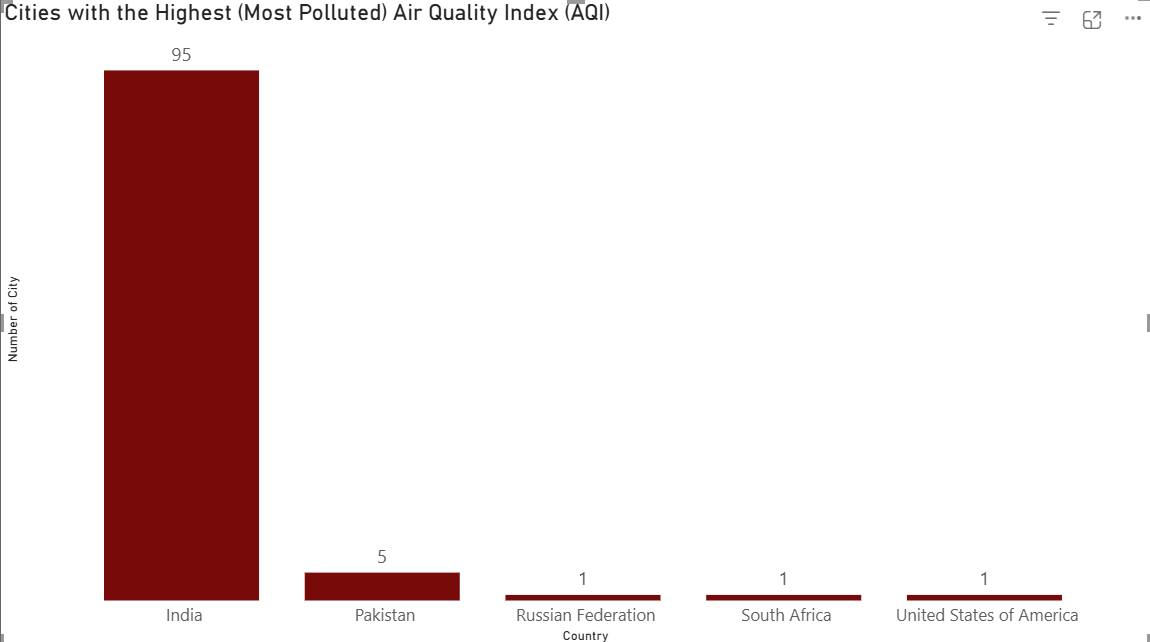

In [26]:
display(Image(filename="C:/Users/hussain/Pictures/Screenshots/polluted city in country.png"))


India has the biggest problem with bad air, with 95 of the most polluted cities. This number is much, much larger than all the other countries. However, all the other nations listed also have cities with very bad air. Pakistan has 5 such cities, and the Russian Federation, South Africa, and the United States each have at least 1 city with extremely poor air quality.









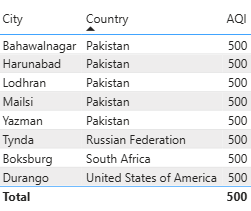

In [27]:
display(Image(filename="C:/Users/hussain/Pictures/Screenshots/Screenshot 2025-10-07 203938.png"))


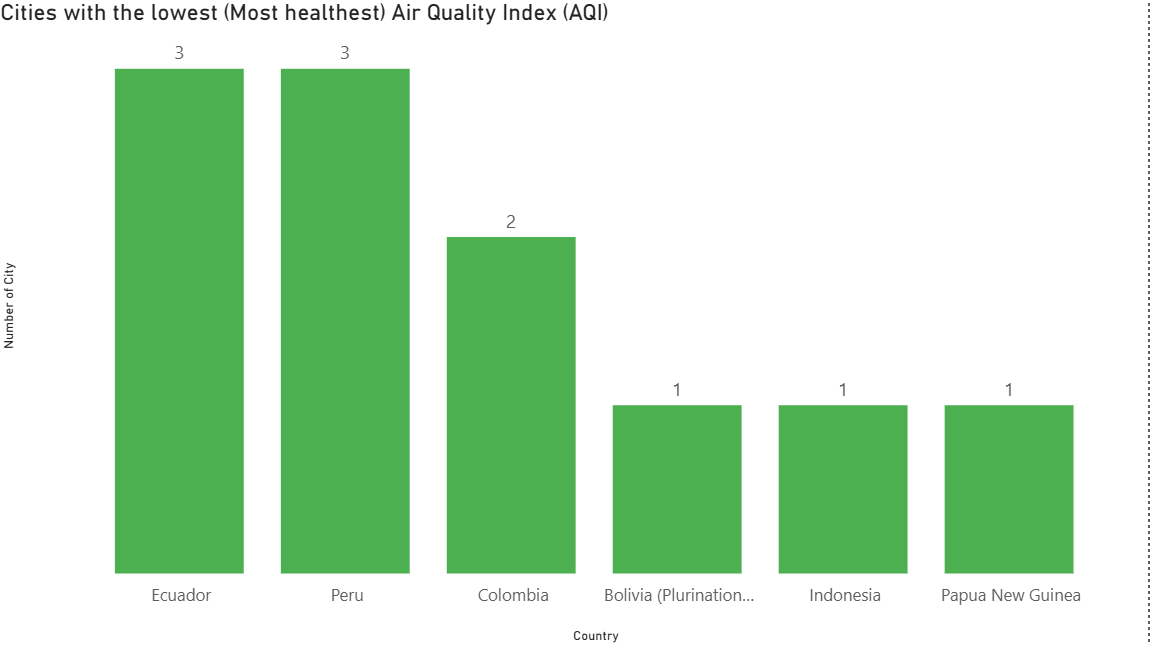

In [28]:
display(Image(filename="C:/Users/hussain/Pictures/Screenshots/Screenshot 2025-10-07 201635.png"))

A number of nations are notable for having the cleanest and best air in their cities.  With three cities in each of the two countries having the lowest Air Quality Index (AQI) values (below 11), Ecuador and Peru share the top spot in the group.  Colombia comes in second with two of these cities.  Additionally, one city each from Papua New Guinea, Indonesia, and Bolivia is included in this list.  This demonstrates that there are areas in various countries, especially in South America, where the air quality is exceptionally good.

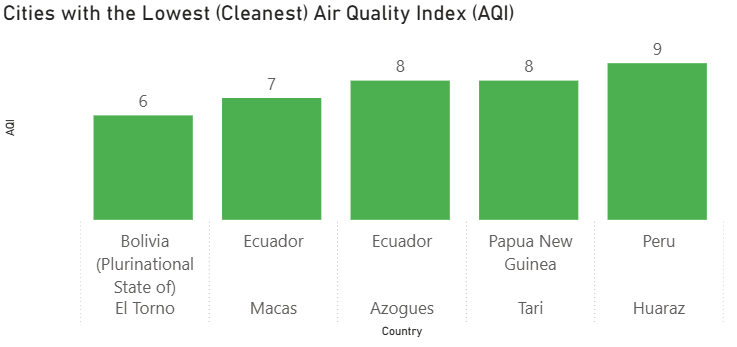

In [29]:
display(Image(filename="C:/Users/hussain/Pictures/Screenshots/Screenshot 2025-10-07 111249.png"))

Several cities boast excellent air quality, registering the lowest Air Quality Index (AQI) scores, which range between 6 and 9. The purest air is recorded in El Torno, Bolivia, with an impressive AQI of 6. Following closely are Macas, Ecuador, with an AQI of 7, and a tie at an AQI of 8 between Azogues, Ecuador, and Tari, Papua New Guinea. Finally, Huaraz, Peru, registers an AQI of 9. This shows that these locations, with a strong presence in South America, are home to some of the globe's healthiest urban air environments.


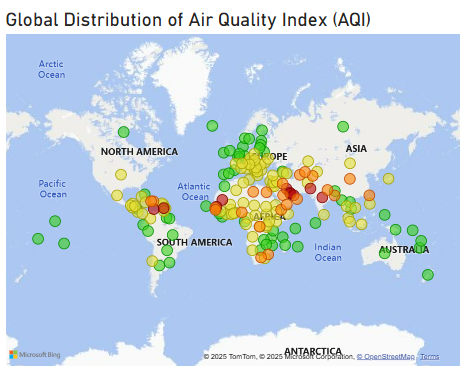

In [30]:
display(Image(filename="C:/Users/hussain/Pictures/Screenshots/Screenshot 2025-10-07 112054.png"))

The global distribution of air quality clearly shows that geographic location significantly impacts air purity. Areas situated along the edges of the continents and near the coasts—especially around the Pacific and North Atlantic Oceans—tend to have clean air (represented by green dots). 
In contrast, as one moves toward the inland and central areas of the major continents, the air quality pattern changes drastically. These central regions show a higher concentration of dots indicating unclean to heavily polluted air (yellow, orange, and red). This pattern is especially noticeable across large parts of Asia, Africa, and Eastern Europe.



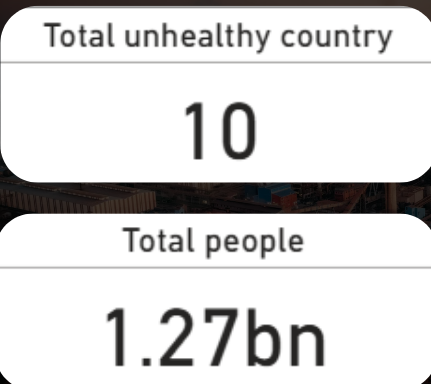

In [31]:
display(Image(filename="C:/Users/hussain/Pictures/Screenshots/Screenshot 2025-10-08 092634.png"))

There are 10 countries where the air is unhealthy, affecting about 1.27 billion people. This means a huge number of people are breathing polluted air every day, which can lead to serious health issues such as asthma, lung disease, and heart problems. The situation shows how important it is for governments and communities to take action to reduce pollution and create a cleaner, safer environment for everyone.

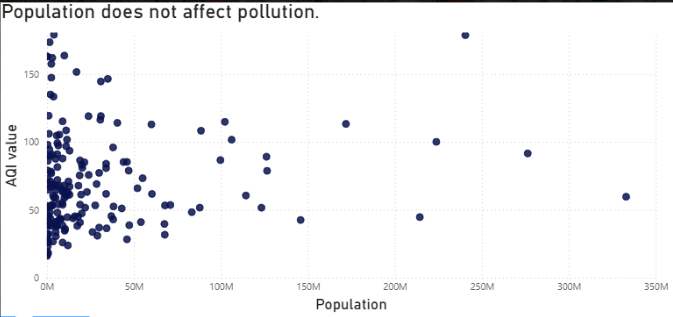

In [32]:
display(Image(filename="C:/Users/hussain/Pictures/Screenshots/Screenshot 2025-10-08 100421.png"))

There is no strong relationship between population size and pollution levels. Some highly populated countries have cleaner air, while some smaller ones experience more pollution. This means that population alone is not the main cause of air pollution; other factors like industry, energy use, and environmental policies have a bigger impact. It shows the importance of focusing on sustainable practices to improve air quality in all countries.

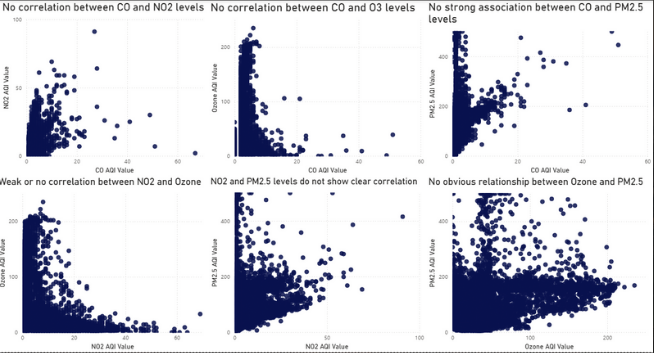

In [33]:
display(Image(filename="C:/Users/hussain/Pictures/Screenshots/Screenshot 2025-10-08 100930.png"))

There is no clear relationship between the different air pollutants such as CO, NO₂, O₃, and PM2.5. Changes in the level of one pollutant do not always affect the others in the same way. This means that each pollutant is influenced by different factors like weather, traffic, and industrial activity. To improve air quality, it is important to address each type of pollution separately and take actions that target all sources effectively.

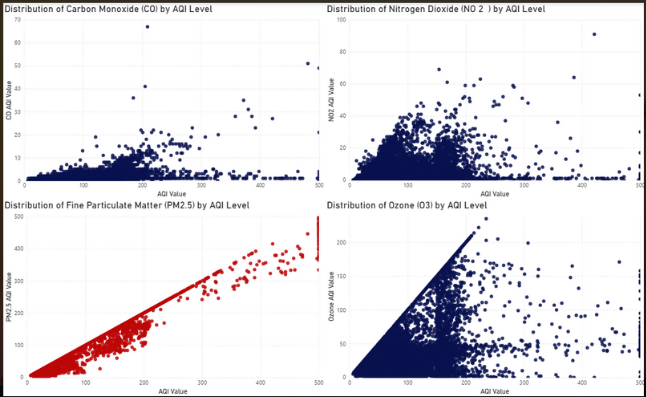

In [34]:
display(Image(filename="C:/Users/hussain/Pictures/Screenshots/Screenshot 2025-10-08 101158.png"))

Fine Particulate Matter (PM2.5) has a major influence on air pollution levels. Because of their extremely small size, these particles can stay suspended in the air for long periods and are easily inhaled, posing serious health risks. Their strong correlation with high AQI values makes them a key contributor to poor air quality.


## Recommendations

From the air quality analysis, Azogues in Ecuador, El Torno in Bolivia, and Huaraz in Peru have some of the cleanest air. These places are great to visit because the air is healthy and the nature is very beautiful. People should think about air quality when they travel. Governments should make stricter rules to control pollution, and factories should avoid using particles that cause air pollution to keep the environment clean and safe.

## Limitations and Assumptions

-Time Limitation:
The data was collected at one point in time, so it doesn’t show changes or trends over different periods.

-Limited Areas Covered:
The data includes only some regions and doesn’t represent the whole world, which may affect how general the results are.

-No Details on Pollution Sources:
The data doesn’t show where the pollution comes from, making it hard to know which sources have the biggest impact.

It’s assumed that the data is correct and represents the areas studied. If this is not true, the results might not be fully accurate.

## References

[1]https://www.who.int/

[2]https://data.worldbank.org/indicator/NY.GDP.PCAP.CD

